# TP DEP LEARNING 

## Etude 2 - CIFAR-10

Classement d'images en 10 catégories à l'aide de réseaux de neurones (MLP et CNN).

### Mise en place d'un bon environnement et architecture de notre dossier

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import cifar10
import pandas as pd

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

## 1. Exploration des données

In [ ]:
# Affichage de la forme des données d'entraînement et de test
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Forme X_train :", X_train.shape)
print("Forme y_train :", y_train.shape)
print("Forme X_test  :", X_test.shape)
print("Forme y_test  :", y_test.shape)

Forme X_train : (50000, 32, 32, 3)
Forme y_train : (50000, 1)
Forme X_test  : (10000, 32, 32, 3)
Forme y_test  : (10000, 1)


In [ ]:
# Affichage des 10 premières étiquettes de y_train et des valeurs uniques
print(y_train[:10])
print("Valeurs uniques :", np.unique(y_train))

[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]
Valeurs uniques : [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Ici on constate qu'on a 10 valeurs uniques y_train, ce qui correspond aux 10 classes d'images présentes dans le dataset CIFAR-10. En regardant la documentation de CIFAR-10 ces valeurs correspondent à : 
classes = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 
           'chien', 'grenouille', 'cheval', 'bateau', 'camion']

In [ ]:
# Nombre d'occurences de chaque classe dans y_train
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]))

<BarContainer object of 10 artists>

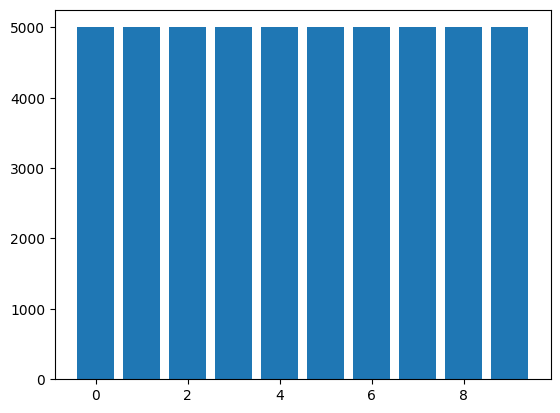

In [ ]:
# Affichage de l'occurence de chaque classe dans y_train
plt.bar(np.unique(y_train), np.unique(y_train, return_counts=True)[1])

In [20]:
# Affichage des premmières valeurs de X_train
print("1ère donnée de X_train :", X_train[0])

1ère donnée de X_train : [[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


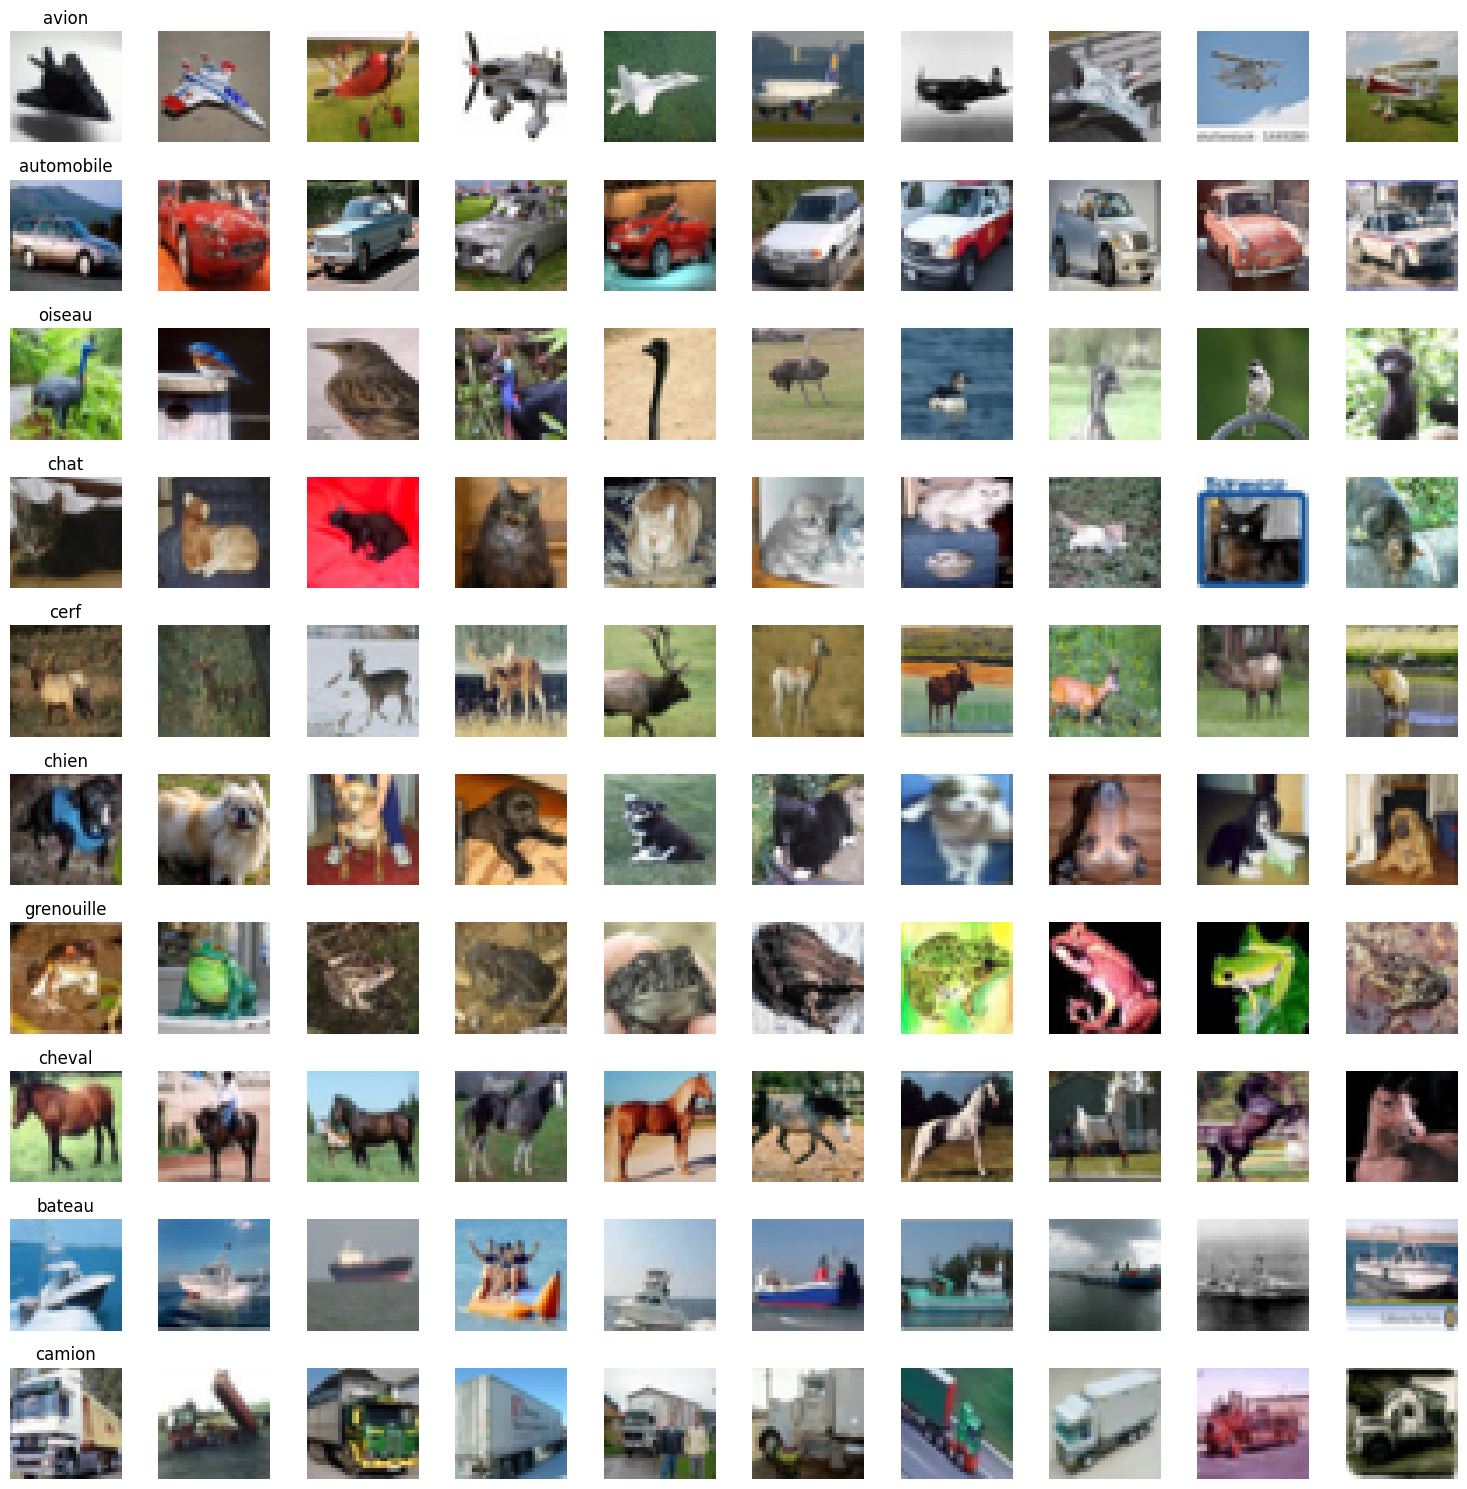

In [ ]:
# Affichage de 10 images de chaque classe
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for classe in range(10):
    indices = np.where(y_train == classe)[0][:10]
    for j in range(10):
        axes[classe][j].imshow(X_train[indices[j]])
        axes[classe][j].axis('off')
        if j == 0:
            axes[classe][0].set_title(classes[classe])

plt.tight_layout()
plt.show()

## 2. Préparation des données

In [32]:
# Normalisation
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print("Min :", X_train.min(), "Max :", X_train.max())

Min : 0.0 Max : 1.0


In [ ]:
# Reshape des étiquettes pour les rendre compatibles avec les modèles de Keras
y_train = y_train.flatten()
y_test  = y_test.flatten()

print(y_train.shape)

(50000,)


## 3 Modèle Baseline

In [38]:
# Le modèle baseline est le premier modèle que nous allons construire pour servir de référence. Nous allons construire un modèle simple de réseau de neurones entièrement connecté (MLP) pour la classification des images du dataset CIFAR-10.
model_baseline = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),  # couche cachée
    keras.layers.Dense(10, activation='softmax'),  # couche de sortie
])
model_baseline.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,666 (385.41 KB)

 Trainable params: 98,666 (385.41 KB)

 Non-trainable params: 0 (0.00 B)

### 3.1 Compiler le modèle

In [44]:
# Une fois qu'on a défini notre modèle, nous allons le compiler en spécifiant la fonction de perte, l'optimiseur et les métriques que nous voulons suivre pendant l'entraînement.
model_baseline.compile( optimizer='sgd', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'] )

### 3.2 Entrainer le modèle

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2767 - loss: 2.0150 - val_accuracy: 0.2609 - val_loss: 2.0548
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3571 - loss: 1.8260 - val_accuracy: 0.3301 - val_loss: 1.8238
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3786 - loss: 1.7633 - val_accuracy: 0.3731 - val_loss: 1.7795
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3941 - loss: 1.7192 - val_accuracy: 0.3875 - val_loss: 1.7309
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4063 - loss: 1.6875 - val_accuracy: 0.3390 - val_loss: 1.8404
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4173 - loss: 1.6568 - val_accuracy: 0.3972 - val_loss: 1.7165
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4264 - loss: 1.6323 - val_accuracy: 0.4148 - val_loss: 1.6538
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4353 - loss: 1.6111 - val_accuracy: 0.

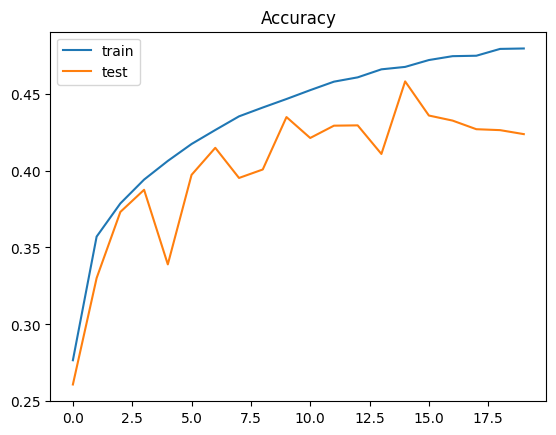

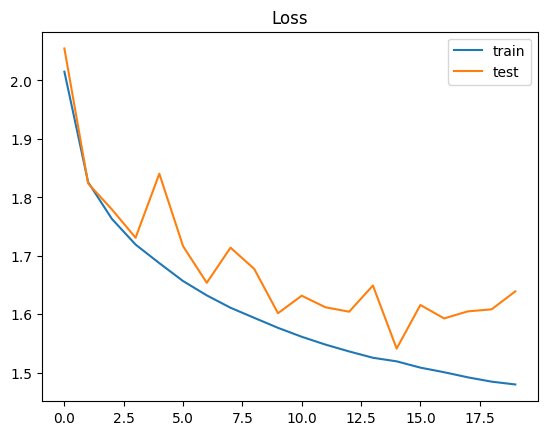

In [45]:
# Entrainer le modèle et stocker l'historique de l'entraînement pour pouvoir afficher les courbes d'apprentissage
history = model_baseline.fit(
    X_train, y_train,
    epochs          = 20,
    batch_size      = 64,
    validation_data = (X_test, y_test)
)

# Afficher les courbes d'apprentissage
# Accuracy
plt.plot(history.history['accuracy'],     label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.title('Loss')
plt.show()

### 3.3 Sauvegarder le modèle et le résultat 

In [47]:
# Sauvegarder et évaluer
model_baseline.save("models/mon_modele.keras")

loss, acc = model_baseline.evaluate(X_test, y_test)
print(f"Accuracy : {acc:.4f}")

baseline_accuracy_final= acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.4237 - loss: 1.6392
Accuracy : 0.4237


##

## 4. Modèle Avancé CNN

### 4.1 CNN sans data-augmentation

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4373 - loss: 1.5731 - val_accuracy: 0.5495 - val_loss: 1.2940
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5572 - loss: 1.2646 - val_accuracy: 0.6013 - val_loss: 1.1514
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5989 - loss: 1.1508 - val_accuracy: 0.6485 - val_loss: 1.0371
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6248 - loss: 1.0797 - val_accuracy: 0.6620 - val_loss: 0.9849
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6444 - loss: 1.0327 - val_accuracy: 0.6747 - val_loss: 0.9580
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6532 - loss: 0.9925 - val_accuracy: 0.6914 - val_loss: 0.9085
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6664 - loss: 0.9598 - val_accuracy: 0.6911 - val_loss: 0.9101
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6748 - loss: 0.9332 - val_accuracy: 0

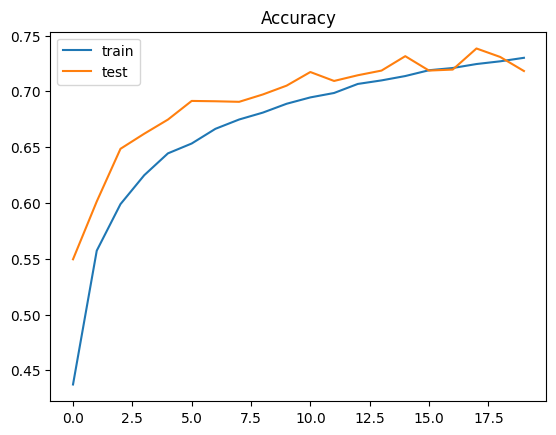

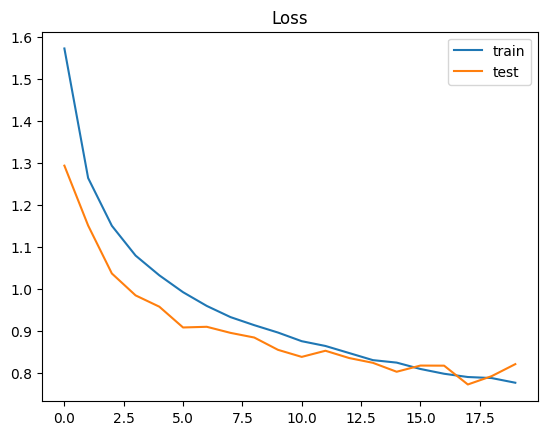

In [52]:
# Mise en place du 1er CNN
cnn_test1= keras.models.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding="same",activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=64, kernel_size=(3,3),activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax") # Pour avoir 10 proba en sortie (une par classe)
   ]
 )
cnn_test1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrainer le modèle et stocker l'historique de l'entraînement pour pouvoir afficher les courbes d'apprentissage
cnn_history1 = cnn_test1.fit(
    X_train, y_train,
    epochs          = 20,
    batch_size      = 64,
    validation_data = (X_test, y_test)
)

# Afficher les courbes d'apprentissage
# Accuracy
plt.plot(cnn_history1.history['accuracy'],     label='train')
plt.plot(cnn_history1.history['val_accuracy'], label='test')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(cnn_history1.history['loss'],     label='train')
plt.plot(cnn_history1.history['val_loss'], label='test')
plt.legend()
plt.title('Loss')
plt.show()

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4163 - loss: 1.6093 - val_accuracy: 0.5108 - val_loss: 1.3866
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5231 - loss: 1.3375 - val_accuracy: 0.5737 - val_loss: 1.2117
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5730 - loss: 1.2196 - val_accuracy: 0.6235 - val_loss: 1.0890
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6007 - loss: 1.1387 - val_accuracy: 0.6387 - val_loss: 1.0601
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6193 - loss: 1.0834 - val_accuracy: 0.6567 - val_loss: 1.0006
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6394 - loss: 1.0379 - val_accuracy: 0.6792 - val_loss: 0.9348
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6468 - loss: 1.0044 - val_accuracy: 0.6763 - val_loss: 0.9257
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6644 - loss: 0.9696 - val_acc

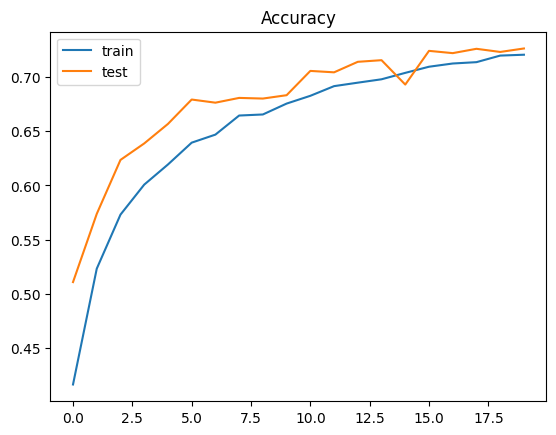

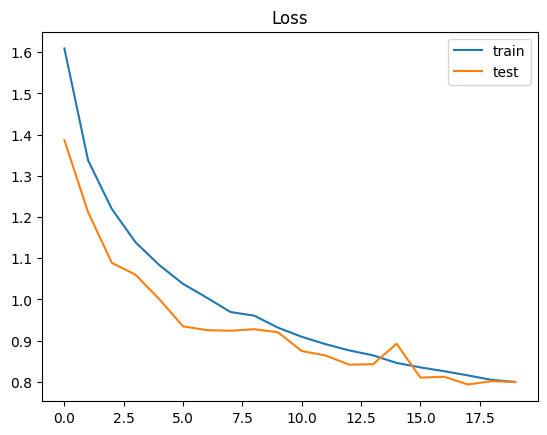

In [53]:
# Mise en place du 2eme CNN
cnn_test2= keras.models.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Conv2D(filters=32, kernel_size=(5,5), padding="same",activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=64, kernel_size=(5,5),activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
   ]
 )
cnn_test2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrainer le modèle et stocker l'historique de l'entraînement pour pouvoir afficher les courbes d'apprentissage
cnn_history2 = cnn_test2.fit(
    X_train, y_train,
    epochs          = 20,
    batch_size      = 64,
    validation_data = (X_test, y_test)
)

# Afficher les courbes d'apprentissage
# Accuracy
plt.plot(cnn_history2.history['accuracy'],     label='train')
plt.plot(cnn_history2.history['val_accuracy'], label='test')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(cnn_history2.history['loss'],     label='train')
plt.plot(cnn_history2.history['val_loss'], label='test')
plt.legend()
plt.title('Loss')
plt.show()

### 4.2 CNN avec Data augmentation
Créer de nouvelles images à partir des existantes en les transformant légèrement : retourner une image, la rogner, changer la luminosité
Il sert à améliorer le modèle en le généralisant et évite l'overfitting

####

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4012 - loss: 1.6632 - val_accuracy: 0.5156 - val_loss: 1.3455
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5020 - loss: 1.4076 - val_accuracy: 0.5621 - val_loss: 1.2483
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5327 - loss: 1.3188 - val_accuracy: 0.5981 - val_loss: 1.1491
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5550 - loss: 1.2581 - val_accuracy: 0.6202 - val_loss: 1.0809
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5710 - loss: 1.2154 - val_accuracy: 0.6318 - val_loss: 1.0542
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5778 - loss: 1.1898 - val_accuracy: 0.6268 - val_loss: 1.0813
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5882 - loss: 1.1676 - val_accuracy: 0.6473 - val_loss: 1.0400
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5969 - loss: 1.1487 - val_acc

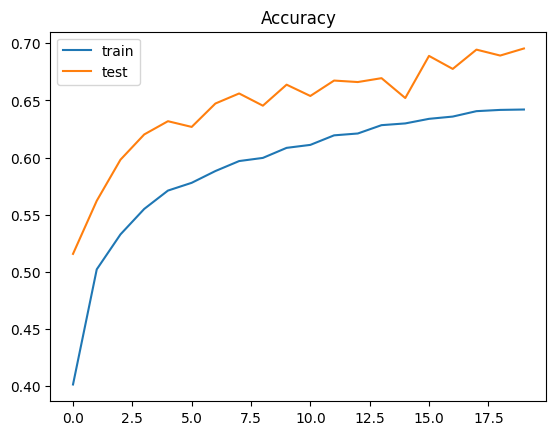

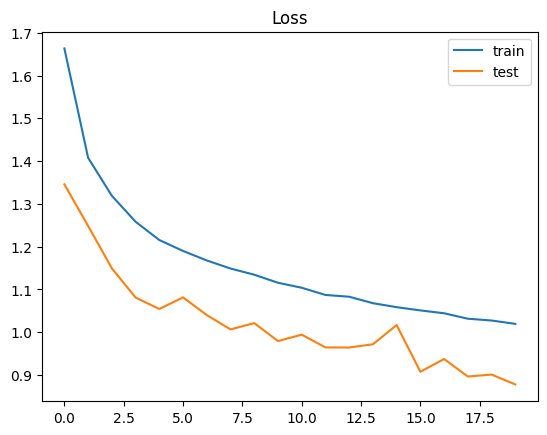

In [55]:
# Ajout de data augmentation
cnn_test3 = keras.models.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    
    # Data augmentation
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomZoom(0.1),
    
    keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(64, (3,3), activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

cnn_test3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history3 = cnn_test3.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Afficher les courbes d'apprentissage
# Accuracy
plt.plot(cnn_history3.history['accuracy'],     label='train')
plt.plot(cnn_history3.history['val_accuracy'], label='test')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(cnn_history3.history['loss'],     label='train')
plt.plot(cnn_history3.history['val_loss'], label='test')
plt.legend()
plt.title('Loss')
plt.show()

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4168 - loss: 1.6081 - val_accuracy: 0.5100 - val_loss: 1.3790
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5369 - loss: 1.3018 - val_accuracy: 0.5913 - val_loss: 1.1557
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5857 - loss: 1.1778 - val_accuracy: 0.6266 - val_loss: 1.0581
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6136 - loss: 1.1049 - val_accuracy: 0.6574 - val_loss: 0.9952
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6318 - loss: 1.0551 - val_accuracy: 0.6656 - val_loss: 0.9718
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6490 - loss: 1.0078 - val_accuracy: 0.6751 - val_loss: 0.9439
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6636 - loss: 0.9694 - val_accuracy: 0.6858 - val_loss: 0.9122
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6689 - loss: 0.9478 - val_acc

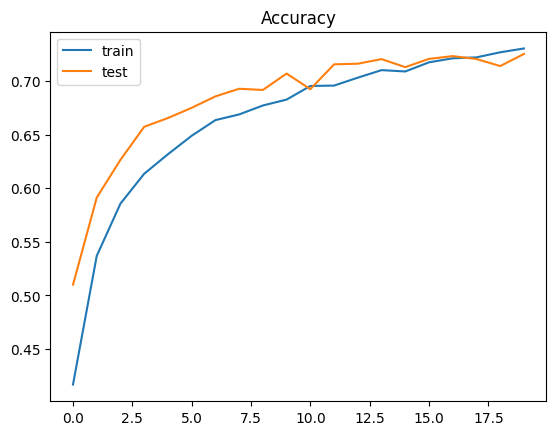

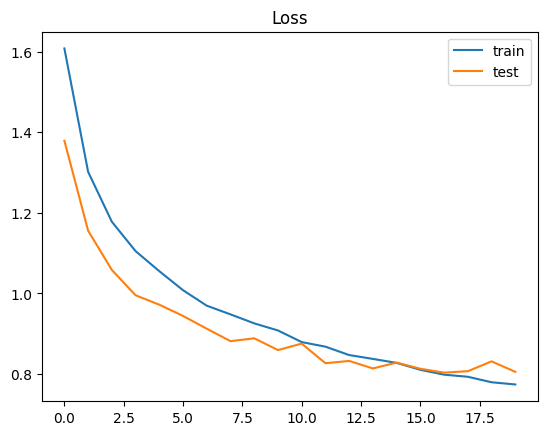

In [56]:
# Mise en place du 2eme CNN data augmentation
cnn_test4= keras.models.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Conv2D(filters=32, kernel_size=(5,5), padding="same",activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=64, kernel_size=(5,5),activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
   ]
 )
cnn_test4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrainer le modèle et stocker l'historique de l'entraînement pour pouvoir afficher les courbes d'apprentissage
cnn_history4 = cnn_test4.fit(
    X_train, y_train,
    epochs          = 20,
    batch_size      = 64,
    validation_data = (X_test, y_test)
)

# Afficher les courbes d'apprentissage
# Accuracy
plt.plot(cnn_history4.history['accuracy'],     label='train')
plt.plot(cnn_history4.history['val_accuracy'], label='test')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(cnn_history4.history['loss'],     label='train')
plt.plot(cnn_history4.history['val_loss'], label='test')
plt.legend()
plt.title('Loss')
plt.show()

In [57]:
# Mettre tout ca au propre 
# Dictionnaires pour stocker les historiques
acc = {}
loss = {}

In [58]:
# Définition des 4 modèles comme fonctions
def cnn1():
    m = keras.models.Sequential([
        keras.layers.Input(shape=(32,32,3)),
        keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Conv2D(64, (3,3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Flatten(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation="softmax")
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m, "CNN1_3x3"

def cnn2():
    m = keras.models.Sequential([
        keras.layers.Input(shape=(32,32,3)),
        keras.layers.Conv2D(32, (5,5), padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Conv2D(64, (5,5), padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Flatten(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation="softmax")
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m, "CNN2_5x5"

def cnn3():
    m = keras.models.Sequential([
        keras.layers.Input(shape=(32,32,3)),
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomTranslation(0.1, 0.1),
        keras.layers.RandomZoom(0.1),
        keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Conv2D(64, (3,3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Flatten(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation="softmax")
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m, "CNN3_3x3_augmented"

def cnn4():
    m = keras.models.Sequential([
        keras.layers.Input(shape=(32,32,3)),
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomTranslation(0.1, 0.1),
        keras.layers.RandomZoom(0.1),
        keras.layers.Conv2D(32, (5,5), padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Conv2D(64, (5,5), padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Flatten(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation="softmax")
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m, "CNN4_5x5_augmented"

In [59]:
# Entraînement des 4 modèles
TAILLE_BATCH = 64
NB_ITERATIONS = 20

for build_fn in [cnn1, cnn2, cnn3, cnn4]:
    model, nom = build_fn()
    print(f"\n--- Entraînement : {nom} ---")
    
    res = model.fit(
        X_train, y_train,
        batch_size=TAILLE_BATCH,
        epochs=NB_ITERATIONS,
        validation_data=(X_test, y_test),
        verbose=1
    )
    
    # Stocker les historiques
    acc[nom+"_train"] = pd.Series(res.history["accuracy"])
    acc[nom+"_val"]   = pd.Series(res.history["val_accuracy"])
    loss[nom+"_train"] = pd.Series(res.history["loss"])
    loss[nom+"_val"]   = pd.Series(res.history["val_loss"])
    
    # Sauvegarder le modèle
    model.save(f"models/{nom}.keras")


--- Entraînement : CNN1_3x3 ---
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4312 - loss: 1.5919 - val_accuracy: 0.5516 - val_loss: 1.2800
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5577 - loss: 1.2595 - val_accuracy: 0.5993 - val_loss: 1.1479
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6031 - loss: 1.1385 - val_accuracy: 0.6465 - val_loss: 1.0365
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6304 - loss: 1.0659 - val_accuracy: 0.6626 - val_loss: 0.9884
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6484 - loss: 1.0133 - val_accuracy: 0.6658 - val_loss: 0.9687
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6611 - loss: 0.9726 - val_accuracy: 0.6819 - val_loss: 0.9349
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6721 - loss: 0.9403 - val_accuracy: 0.6881 - val_loss: 0.9145
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6807 

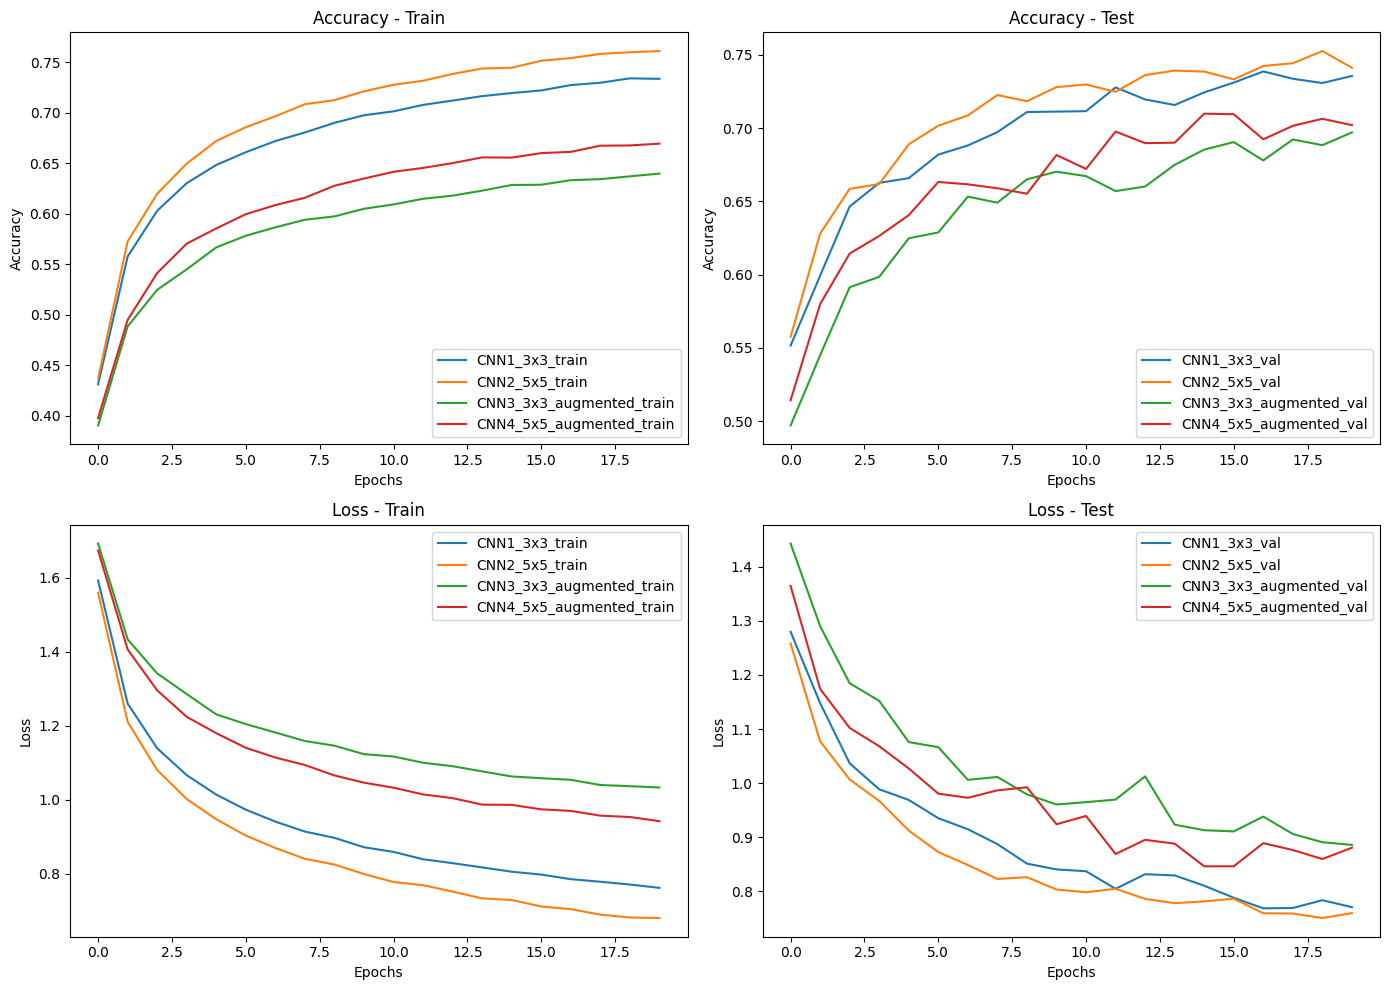

In [60]:
# 4 graphiques séparés
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy train
pd.DataFrame({k:v for k,v in acc.items() if "train" in k}).plot(ax=axes[0,0])
axes[0,0].set_title("Accuracy - Train")
axes[0,0].set_xlabel("Epochs")
axes[0,0].set_ylabel("Accuracy")

# Accuracy test
pd.DataFrame({k:v for k,v in acc.items() if "val" in k}).plot(ax=axes[0,1])
axes[0,1].set_title("Accuracy - Test")
axes[0,1].set_xlabel("Epochs")
axes[0,1].set_ylabel("Accuracy")

# Loss train
pd.DataFrame({k:v for k,v in loss.items() if "train" in k}).plot(ax=axes[1,0])
axes[1,0].set_title("Loss - Train")
axes[1,0].set_xlabel("Epochs")
axes[1,0].set_ylabel("Loss")

# Loss test
pd.DataFrame({k:v for k,v in loss.items() if "val" in k}).plot(ax=axes[1,1])
axes[1,1].set_title("Loss - Test")
axes[1,1].set_xlabel("Epochs")
axes[1,1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("outputs/comparaison_modeles.png")
plt.show()

In [61]:
# enregistrer resultat sur pickle 
import pickle 
# Sauvegarde du contenu de « acc » dans un fichier nommé « data_res.pickle » 
f = open("outputs/data_acc.pickle", "wb")     
# Attention le “b” est important 
pickle.dump(acc, f) 
f.close() 
# Chargement des données du fichier « data_acc.pickle » dans une variable « acc » 
f = open("outputs/data_acc.pickle", "rb")     
# Attention le “b” est important 
acc = pickle.load(f) 
f.close() 

# Sauvegarde du contenu de « loss » dans un fichier nommé « data_res.pickle » 
f = open("outputs/data_loss.pickle", "wb")     
# Attention le “b” est important 
pickle.dump(loss, f) 
f.close() 
# Chargement des données du fichier « data_loss.pickle » dans une variable « loss » 
f = open("outputs/data_loss.pickle", "rb")     
# Attention le “b” est important 
loss = pickle.load(f) 
f.close() 

In [62]:
# Charger le meilleur modèle
best_model = keras.models.load_model("models/CNN2_5x5.keras")

# Prédictions
y_pred_proba = best_model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)

# Trouver les erreurs
errors = [i for i in range(len(y_pred)) if y_pred[i] != y_test[i]]
print(f"Erreurs : {len(errors)} / {len(y_test)}")
print(f"Accuracy : {1 - len(errors)/len(y_test):.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Erreurs : 2589 / 10000
Accuracy : 0.7411


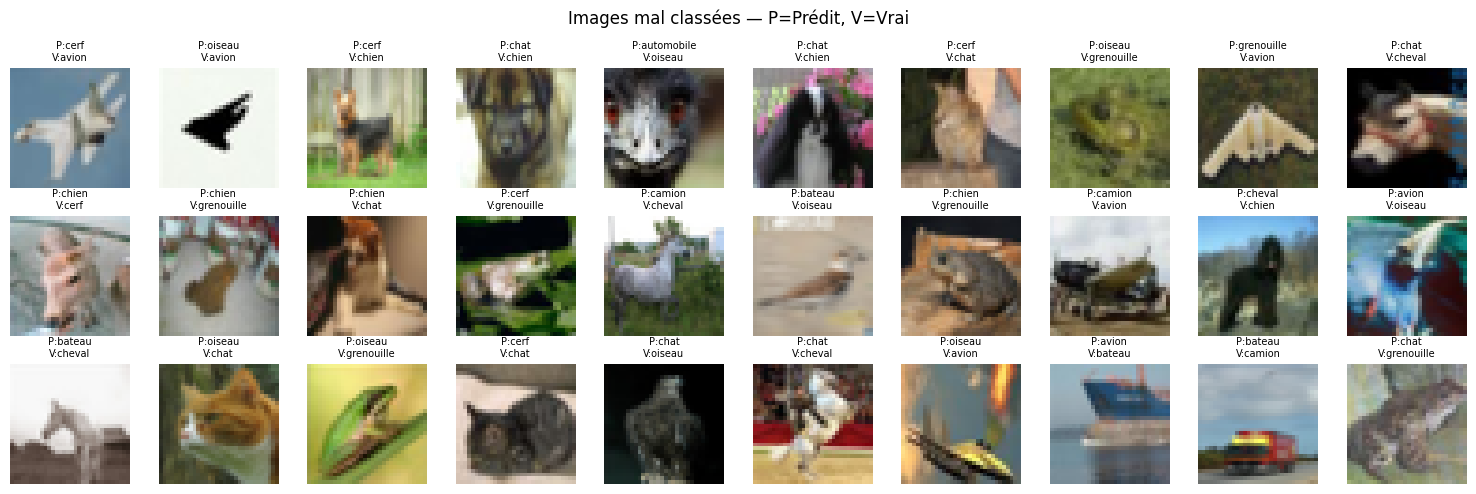

In [63]:
classes = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 
           'chien', 'grenouille', 'cheval', 'bateau', 'camion']

# Afficher 30 images mal classées
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for idx, ax in zip(errors[:30], axes.flat):
    ax.imshow(X_test[idx])
    ax.set_title(f"P:{classes[y_pred[idx]]}\nV:{classes[y_test[idx]]}", 
                 fontsize=7)
    ax.axis('off')

plt.suptitle("Images mal classées — P=Prédit, V=Vrai")
plt.tight_layout()
plt.savefig("outputs/erreurs_images.png")
plt.show()

In [64]:
import numpy as np

# Compter les erreurs par classe
for i, classe in enumerate(classes):
    idx_classe = np.where(y_test == i)[0]
    erreurs_classe = [j for j in idx_classe if y_pred[j] != y_test[j]]
    print(f"{classe:12} : {len(erreurs_classe)} erreurs / {len(idx_classe)} ({len(erreurs_classe)/len(idx_classe)*100:.1f}%)")

avion        : 214 erreurs / 1000 (21.4%)
automobile   : 160 erreurs / 1000 (16.0%)
oiseau       : 396 erreurs / 1000 (39.6%)
chat         : 442 erreurs / 1000 (44.2%)
cerf         : 309 erreurs / 1000 (30.9%)
chien        : 304 erreurs / 1000 (30.4%)
grenouille   : 217 erreurs / 1000 (21.7%)
cheval       : 225 erreurs / 1000 (22.5%)
bateau       : 157 erreurs / 1000 (15.7%)
camion       : 165 erreurs / 1000 (16.5%)
